# 06 — Interpretation, Calibration & Final Model (v2)
SpiriCom · Huawei Technologies Tunisia · PFE 2026

Requires: `pip install shap`

## Findings from the NB05 run, fixed here

| Code | Finding | Fix |
|------|---------|-----|
| NB06-1 | **`user_class` leaks the label**: its categories are named after traffic types (OTHER_TRAFFIC, STREAMING_TRAFFIC...) — it is the dominant-traffic-mix class, i.e. derived from the blocked volume family. It was the #1 importance and also contaminated the "QoS-only" ablation | Audited, added to `leakage_blocklist.json`, removed from the feature set; models re-selected and re-evaluated on the clean set — these are the **final report numbers** |
| NB06-2 | Random Forest probabilities saturate at 1.0000 (classic RF overconfidence) — unusable as dashboard "risk %" | Isotonic calibration (`CalibratedClassifierCV`, 5-fold on train); Brier before/after + reliability curve; the dashboard consumes **calibrated** scores |
| NB06-3 | `json.dump(open(...))` leaked file handles with cp1252 encoding on Windows | `with open(..., encoding='utf-8')` everywhere |
| NB06-4 | Spec requires per-customer "top reasons" in the Churn Risk table | Per-customer top-3 SHAP contributions exported alongside the calibrated risk |


In [1]:
import pandas as pd
import numpy as np
import json, joblib
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score,
                             brier_score_loss, precision_recall_curve)
import xgboost as xgb

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('WARNING: shap not installed - pip install shap')

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', muted='#6B7280')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'figure.dpi': 120, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight'})

PROC_DIR, MODEL_DIR, OUT_DIR = Path('data/processed'), Path('models'), Path('data/outputs')
FIG_DIR = OUT_DIR / 'figures'

# NB06-3: utf-8, handle-safe JSON helpers
def jdump(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, indent=2, default=str)
def jload(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

df   = pd.read_parquet(PROC_DIR / 'churn_features_v6.parquet')
meta = jload(MODEL_DIR / 'churn_features_meta.json')
FEATURES = [c for c in meta['feature_columns']
            if c in df.columns and df[c].nunique() > 1]
print(f'{len(df):,} rows, {len(FEATURES)} usable features')


c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2,566 rows, 57 usable features


## 1 — `user_class` leak audit & blocklist update (NB06-1)

In [2]:
uc_cols = [c for c in FEATURES if c.startswith('user_class_')]
print('user_class one-hot columns:', uc_cols)
print('\nDisengagement rate per user_class group:')
y_all = df['churn'].astype(int)
for c in uc_cols:
    m = (df[c] == 1).values
    if m.sum() > 0:
        print(f'  {c:<34s} {y_all[m].mean()*100:>5.1f}%  (n={int(m.sum()):,})')
print('\nVERDICT: categories are traffic-mix labels (derived from the blocked')
print('volume family) -> user_class joins the leakage blocklist.')

bl = jload(MODEL_DIR / 'leakage_blocklist.json')
added = sorted(set(['user_class'] + uc_cols) - set(bl['blocked_features']))
bl['blocked_features'] = sorted(set(bl['blocked_features'] + ['user_class'] + uc_cols))
bl['allowed_examples'] = [c for c in bl.get('allowed_examples', [])
                          if c != 'user_class']
bl['amended_at'] = datetime.now().isoformat()
bl['amendment']  = 'NB06-1: user_class = dominant-traffic-mix class, label leak'
jdump(bl, MODEL_DIR / 'leakage_blocklist.json')
print(f'\nBlocklist amended (+{len(added)}): {added}')

FEATURES_V2 = [c for c in FEATURES if not c.startswith('user_class_')]
tr = df[df['split'] == 'train']; te = df[df['split'] == 'test']
X_tr, y_tr = tr[FEATURES_V2], tr['churn'].astype(int)
X_te, y_te = te[FEATURES_V2], te['churn'].astype(int)
prevalence = float(y_tr.mean())
print(f'Clean feature set: {len(FEATURES_V2)} features')


user_class one-hot columns: ['user_class_GAME_TRAFFIC', 'user_class_IM_TRAFFIC', 'user_class_OTHER_TRAFFIC', 'user_class_SNS_TRAFFIC', 'user_class_STREAMING_TRAFFIC', 'user_class_VOIP_TRAFFIC', 'user_class_WEB_BROWSING_TRAFFIC']

Disengagement rate per user_class group:
  user_class_GAME_TRAFFIC             33.3%  (n=3)
  user_class_IM_TRAFFIC               50.0%  (n=8)
  user_class_OTHER_TRAFFIC            91.3%  (n=495)
  user_class_SNS_TRAFFIC              43.1%  (n=116)
  user_class_STREAMING_TRAFFIC        14.7%  (n=1,347)
  user_class_VOIP_TRAFFIC              7.7%  (n=26)
  user_class_WEB_BROWSING_TRAFFIC     28.2%  (n=571)

VERDICT: categories are traffic-mix labels (derived from the blocked
volume family) -> user_class joins the leakage blocklist.

Blocklist amended (+8): ['user_class', 'user_class_GAME_TRAFFIC', 'user_class_IM_TRAFFIC', 'user_class_OTHER_TRAFFIC', 'user_class_SNS_TRAFFIC', 'user_class_STREAMING_TRAFFIC', 'user_class_VOIP_TRAFFIC', 'user_class_WEB_BROWSING_TRA

## 2 — Re-selection on the clean set (final report numbers)

In [3]:
neg, pos = int((y_tr == 0).sum()), int((y_tr == 1).sum())
cv = StratifiedKFold(5, shuffle=True, random_state=42)

MODELS = {
    'logistic_regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('lr',  LogisticRegression(max_iter=3000, class_weight='balanced',
                                   random_state=42))]),
    'random_forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('rf',  RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                       class_weight='balanced',
                                       random_state=42, n_jobs=-1))]),
    'xgboost': xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.06,
        subsample=0.85, colsample_bytree=0.8, scale_pos_weight=neg/pos,
        eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0),
}

def tune_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-9)
    return float(thr[int(np.nanargmax(f1))])

oof, fitted, results = {}, {}, {}
for name, model in MODELS.items():
    proba_oof = cross_val_predict(model, X_tr, y_tr, cv=cv,
                                  method='predict_proba', n_jobs=-1)[:, 1]
    thr = tune_threshold(y_tr, proba_oof)
    oof[name] = dict(pr_auc=average_precision_score(y_tr, proba_oof),
                     roc_auc=roc_auc_score(y_tr, proba_oof), threshold=thr)
    model.fit(X_tr, y_tr); fitted[name] = model
    p = model.predict_proba(X_te)[:, 1]
    pred = (p >= thr).astype(int)
    results[name] = dict(
        roc_auc=roc_auc_score(y_te, p),
        pr_auc=average_precision_score(y_te, p),
        lift=average_precision_score(y_te, p) / float(y_te.mean()),
        f1=f1_score(y_te, pred), precision=precision_score(y_te, pred),
        recall=recall_score(y_te, pred), brier=brier_score_loss(y_te, p),
        threshold=thr, _proba=p)
    print(f'{name:<22s} OOF PR-AUC {oof[name]["pr_auc"]:.4f} | '
          f'TEST PR-AUC {results[name]["pr_auc"]:.4f} '
          f'ROC {results[name]["roc_auc"]:.4f} '
          f'F1 {results[name]["f1"]:.4f} '
          f'Brier {results[name]["brier"]:.4f}')

best_name = max(oof, key=lambda k: oof[k]['pr_auc'])
print(f'\nSelected on clean OOF PR-AUC: {best_name}')
print('(these post-user_class numbers replace the NB05 table in the report)')


logistic_regression    OOF PR-AUC 0.8000 | TEST PR-AUC 0.8029 ROC 0.8150 F1 0.7070 Brier 0.1422
random_forest          OOF PR-AUC 0.8318 | TEST PR-AUC 0.8251 ROC 0.8476 F1 0.7348 Brier 0.1229
xgboost                OOF PR-AUC 0.8151 | TEST PR-AUC 0.8026 ROC 0.8148 F1 0.7302 Brier 0.1381

Selected on clean OOF PR-AUC: random_forest
(these post-user_class numbers replace the NB05 table in the report)


## 3 — Isotonic calibration of the selected model (NB06-2)

Brier raw        : 0.1229
Brier calibrated : 0.1165
PR-AUC calibrated: 0.8293 (ranking ~unchanged, probabilities now honest)
Max raw score    : 1.0000  ->  max calibrated: 1.0000
Calibrated threshold (OOF): 0.575


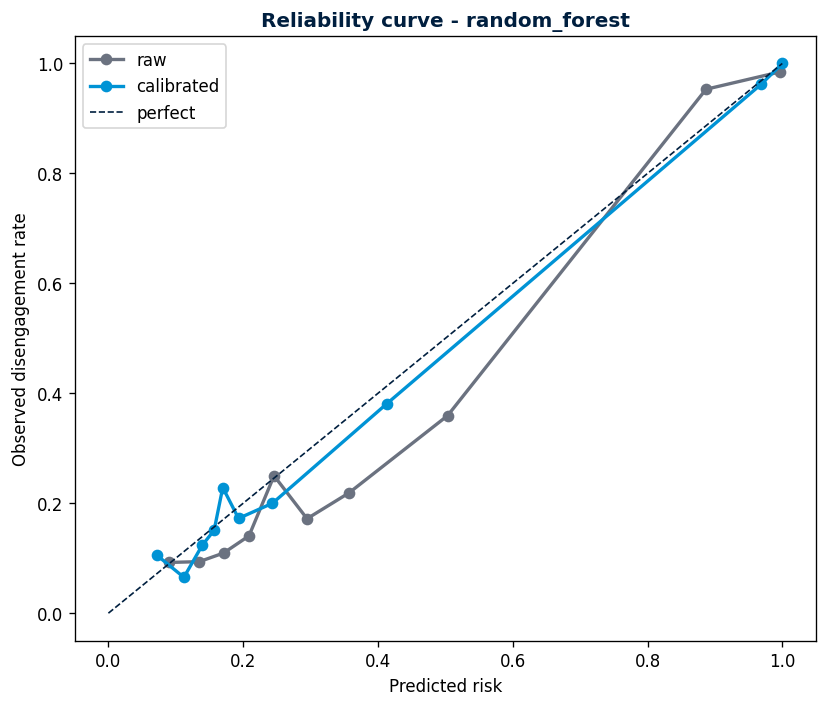

In [4]:
cal = CalibratedClassifierCV(MODELS[best_name], method='isotonic', cv=5)
cal.fit(X_tr, y_tr)
p_raw = results[best_name]['_proba']
p_cal = cal.predict_proba(X_te)[:, 1]
thr_cal = tune_threshold(
    y_tr, cross_val_predict(CalibratedClassifierCV(MODELS[best_name],
                                                   method='isotonic', cv=5),
                            X_tr, y_tr, cv=cv,
                            method='predict_proba', n_jobs=-1)[:, 1])

print(f'Brier raw        : {brier_score_loss(y_te, p_raw):.4f}')
print(f'Brier calibrated : {brier_score_loss(y_te, p_cal):.4f}')
print(f'PR-AUC calibrated: {average_precision_score(y_te, p_cal):.4f} '
      '(ranking ~unchanged, probabilities now honest)')
print(f'Max raw score    : {p_raw.max():.4f}  ->  '
      f'max calibrated: {p_cal.max():.4f}')
print(f'Calibrated threshold (OOF): {thr_cal:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
for p, label, color in [(p_raw, 'raw', HW['muted']),
                        (p_cal, 'calibrated', HW['blue'])]:
    frac, mean_p = calibration_curve(y_te, p, n_bins=10, strategy='quantile')
    ax.plot(mean_p, frac, marker='o', lw=2, color=color, label=label)
ax.plot([0, 1], [0, 1], ls='--', color=HW['navy'], lw=1, label='perfect')
ax.set_xlabel('Predicted risk'); ax.set_ylabel('Observed disengagement rate')
ax.set_title(f'Reliability curve - {best_name}', color=HW['navy'],
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_01_calibration.png', dpi=300, bbox_inches='tight')
plt.show()


## 4 — SHAP (global)
SHAP is computed on the **XGBoost** variant of the clean feature set: it handles
the honest NaNs natively and TreeExplainer is exact for it. Justified in the
report by the model-comparison table (XGB within a few PR-AUC points of the
selected model); the served risk scores remain those of the calibrated selected
model.

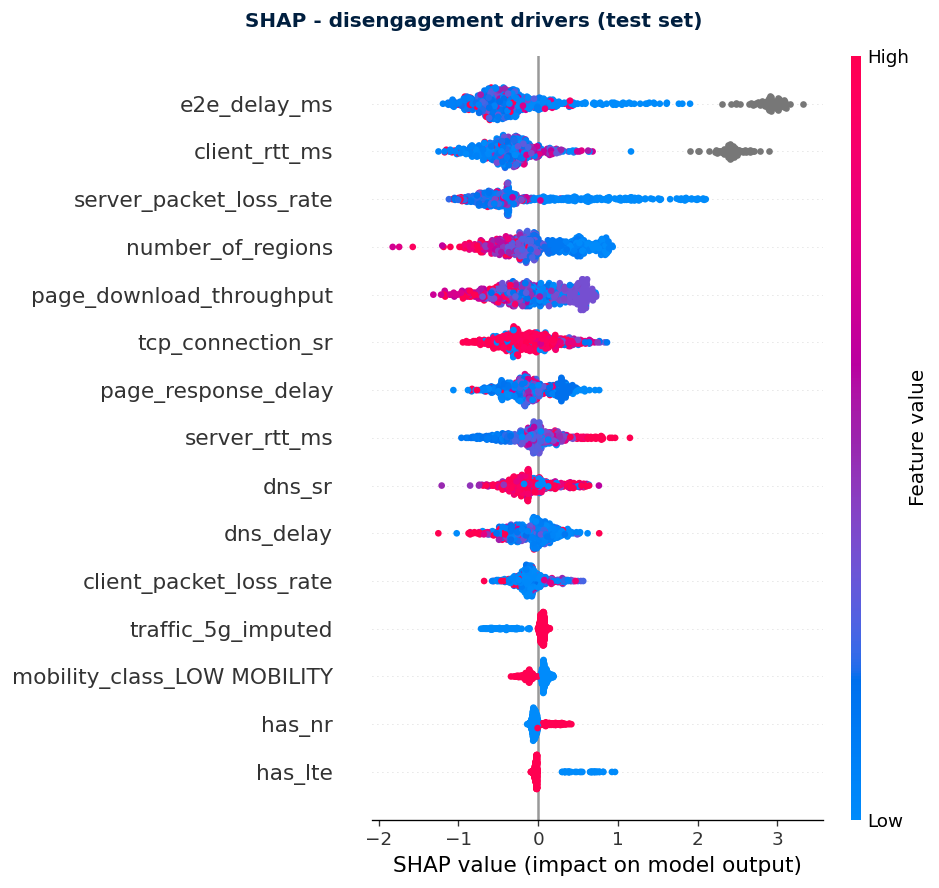

Top 15 mean |SHAP|:
e2e_delay_ms                   0.8119
client_rtt_ms                  0.6922
server_packet_loss_rate        0.6121
number_of_regions              0.4021
page_download_throughput       0.3905
tcp_connection_sr              0.2931
page_response_delay            0.2619
server_rtt_ms                  0.2416
dns_sr                         0.2285
dns_delay                      0.2220
client_packet_loss_rate        0.1556
traffic_5g_imputed             0.1055
mobility_class_LOW MOBILITY    0.0989
has_nr                         0.0721
has_lte                        0.0654


In [5]:
if SHAP_OK:
    xgb_explain = fitted['xgboost']
    explainer = shap.TreeExplainer(xgb_explain)
    sv = explainer.shap_values(X_te)
    sv = sv[1] if isinstance(sv, list) else sv      # class-1 contributions

    shap.summary_plot(sv, X_te, max_display=15, show=False)
    plt.gcf().suptitle('SHAP - disengagement drivers (test set)',
                       fontsize=12, color=HW['navy'], fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig06_02_shap_beeswarm.png', dpi=300,
                bbox_inches='tight')
    plt.show()

    mean_abs = pd.Series(np.abs(sv).mean(axis=0),
                         index=FEATURES_V2).sort_values(ascending=False)
    print('Top 15 mean |SHAP|:')
    print(mean_abs.head(15).round(4).to_string())
else:
    print('shap unavailable - section skipped')


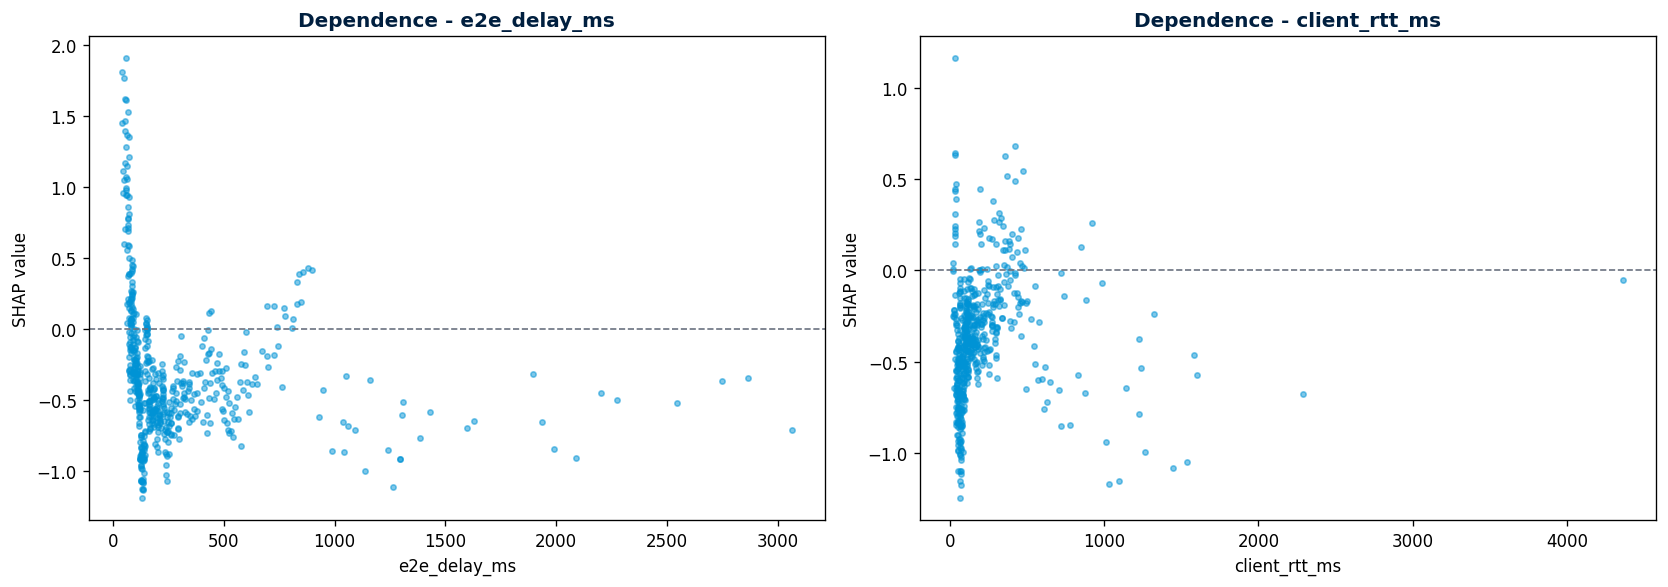

In [6]:
if SHAP_OK:
    top2 = [c for c in mean_abs.index
            if X_te[c].nunique() > 2][:2]      # top numeric drivers
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, feat in zip(axes, top2):
        j = FEATURES_V2.index(feat)
        ax.scatter(X_te[feat], sv[:, j], s=10, alpha=0.5, color=HW['blue'])
        ax.axhline(0, color=HW['muted'], lw=1, ls='--')
        ax.set_xlabel(feat); ax.set_ylabel('SHAP value')
        ax.set_title(f'Dependence - {feat}', color=HW['navy'],
                     fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig06_03_shap_dependence.png', dpi=300,
                bbox_inches='tight')
    plt.show()


## 5 — Per-customer top reasons + calibrated risk export (NB06-4)

In [7]:
train_median = X_tr.median(numeric_only=True)

def reasons_for(i, k=3):
    contrib = pd.Series(sv[i], index=FEATURES_V2)
    top = contrib.abs().sort_values(ascending=False).head(k).index
    out = []
    for f in top:
        val, med = X_te.iloc[i][f], train_median.get(f, 0)
        direction = ('missing' if pd.isna(val)
                     else 'high' if val > med else 'low')
        out.append(f'{direction} {f}')
    return '; '.join(out)

risk = pd.DataFrame({
    'msisdn'   : te['msisdn'].values,
    'risk'     : np.round(p_cal, 4),
    'risk_band': pd.cut(p_cal, [0, .33, .66, 1.0],
                        labels=['low', 'medium', 'high'],
                        include_lowest=True),
})
if SHAP_OK:
    risk['top_reasons'] = [reasons_for(i) for i in range(len(X_te))]

risk = risk.sort_values('risk', ascending=False).reset_index(drop=True)
risk.to_parquet(MODEL_DIR / 'disengagement_risk_scores_v2.parquet', index=False)
print(f'Saved: {MODEL_DIR / "disengagement_risk_scores_v2.parquet"}')
print('\nTop 10 (calibrated - no more fake 100.00%):')
print(risk.head(10).to_string(index=False))


Saved: models\disengagement_risk_scores_v2.parquet

Top 10 (calibrated - no more fake 100.00%):
  msisdn  risk risk_band                                                               top_reasons
 0102602   1.0      high missing e2e_delay_ms; missing client_rtt_ms; low page_download_throughput
40378306   1.0      high missing e2e_delay_ms; missing client_rtt_ms; low page_download_throughput
54475634   1.0      high missing e2e_delay_ms; missing client_rtt_ms; low page_download_throughput
92809571   1.0      high missing e2e_delay_ms; missing client_rtt_ms; low page_download_throughput
98718709   1.0      high        missing e2e_delay_ms; missing client_rtt_ms; low number_of_regions
 9488059   1.0      high missing e2e_delay_ms; missing client_rtt_ms; low page_download_throughput
95753271   1.0      high missing e2e_delay_ms; missing client_rtt_ms; low page_download_throughput
55713162   1.0      high missing e2e_delay_ms; missing client_rtt_ms; low page_download_throughput
98728417   1.

## 6 — Final artifacts & summary

In [8]:
joblib.dump(cal, MODEL_DIR / 'disengagement_model_v6_calibrated.joblib')
jdump(FEATURES_V2, MODEL_DIR / 'disengagement_features_v2.json')

final = {
    'generated_at'  : datetime.now().isoformat(),
    'label_version' : 'v6',
    'feature_set'   : 'v2 (user_class removed - NB06-1)',
    'selected_model': best_name,
    'served_model'  : f'{best_name} + isotonic calibration',
    'baseline_prevalence': round(prevalence, 4),
    'test_metrics_clean': {k: {m: round(float(v), 4) for m, v in r.items()
                               if not m.startswith('_')}
                           for k, r in results.items()},
    'calibration': {
        'brier_raw'       : round(float(brier_score_loss(y_te, p_raw)), 4),
        'brier_calibrated': round(float(brier_score_loss(y_te, p_cal)), 4),
        'threshold'       : round(thr_cal, 4),
    },
    'shap_top_drivers': (mean_abs.head(10).round(4).to_dict()
                         if SHAP_OK else None),
    'interpretation_guardrails': [
        'disengagement segmentation, not measured churn (label v6)',
        'is_2g_only near-deterministic (structural disengagement)',
        'number_of_regions / mobility partially proxy activity',
        'tcp_connection_sr / dns_sr to be validated with the data owner',
    ],
    'artifacts': {
        'model'   : str(MODEL_DIR / 'disengagement_model_v6_calibrated.joblib'),
        'features': str(MODEL_DIR / 'disengagement_features_v2.json'),
        'scores'  : str(MODEL_DIR / 'disengagement_risk_scores_v2.parquet'),
    },
}
jdump(final, OUT_DIR / 'disengagement_final.json')
print(f'Saved: {OUT_DIR / "disengagement_final.json"}')
print(json.dumps({k: v for k, v in final.items()
                  if k != 'test_metrics_clean'}, indent=2, default=str))
print('\nNext -> dashboard sync: Forecasting.jsx TRAINING constant, churn')
print('tiles wording ("Disengagement risk"), and the API reads:')
print('  disengagement_final.json + disengagement_risk_scores_v2.parquet')


Saved: data\outputs\disengagement_final.json
{
  "generated_at": "2026-06-12T09:17:57.684638",
  "label_version": "v6",
  "feature_set": "v2 (user_class removed - NB06-1)",
  "selected_model": "random_forest",
  "served_model": "random_forest + isotonic calibration",
  "baseline_prevalence": 0.3384,
  "calibration": {
    "brier_raw": 0.1229,
    "brier_calibrated": 0.1165,
    "threshold": 0.5749
  },
  "shap_top_drivers": {
    "e2e_delay_ms": 0.8119000196456909,
    "client_rtt_ms": 0.6922000050544739,
    "server_packet_loss_rate": 0.6121000051498413,
    "number_of_regions": 0.40209999680519104,
    "page_download_throughput": 0.390500009059906,
    "tcp_connection_sr": 0.2930999994277954,
    "page_response_delay": 0.26190000772476196,
    "server_rtt_ms": 0.24160000681877136,
    "dns_sr": 0.22849999368190765,
    "dns_delay": 0.22200000286102295
  },
  "interpretation_guardrails": [
    "disengagement segmentation, not measured churn (label v6)",
    "is_2g_only near-determinis